# Visualize the results from the CSVs

In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, Tuple, Optional, List, Union
import warnings
import cartopy.crs as ccrs
import os 


In [2]:
def save_fig(fig, name, dpi=150, directory=None):
    """Helper to save a matplotlib figure into the analysis folder"""
    fname = os.path.join(directory, name)
    fig.savefig(fname, bbox_inches='tight', dpi=dpi)

### From CSVs

##### CO2 Emissions Analysis


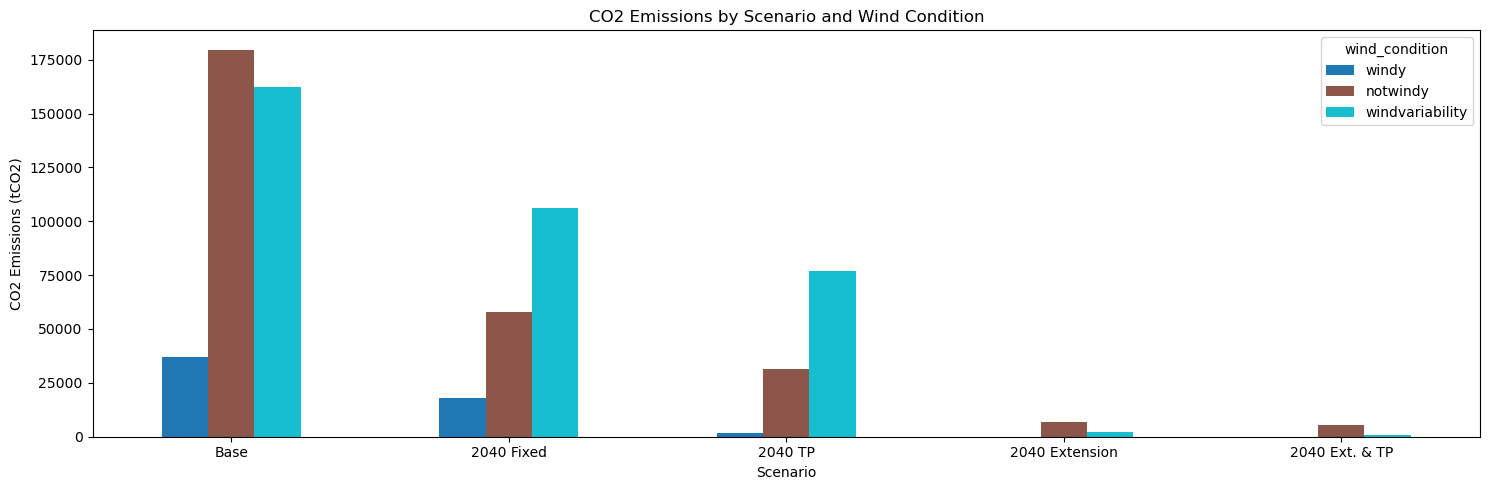

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
csv_directory = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/"
csv_path = f"{csv_directory}run_comparison_summary_all_networks.csv"
summary_df = pd.read_csv(csv_path)

scenario_names = {
    "germany_base2_" : "Base",
    "germany_scenario2040-fixed" : "2040 Fixed",
    "germany_scenario2040-TP" : "2040 TP",
    "germany_scenario2040-ext" : "2040 Extension",
    "germany_scenario2040-ext-TP" : "2040 Ext. & TP"
}

# Ensure wind_condition exists
if 'wind_condition' not in summary_df.columns:
    summary_df['wind_condition'] = summary_df['scenario'].astype(str).apply(lambda s: s.rsplit('_', 1)[-1] if '_' in s else '')
summary_df['wind_condition'] = summary_df['wind_condition'].fillna('unknown')

# Derive scenario base (everything before last underscore)
summary_df['scenario_base'] = summary_df['scenario'].astype(str).apply(lambda s: s.rsplit('_', 1)[0] if '_' in s else s)

# Normalize scenario_names keys (strip trailing underscores) and map to display names
norm_names = {k.rstrip('_'): v for k, v in scenario_names.items()}
summary_df['display_name'] = summary_df['scenario_base'].map(norm_names).fillna(summary_df['scenario_base'])

# Create an ordered list of display names in the order provided (preserve dict order)
scenario_order = [v for k, v in scenario_names.items()]

# Aggregate CO2 by display_name x wind_condition
pivot_df = summary_df.pivot_table(
    index='display_name',
    columns='wind_condition',
    values='total_co2_emissions',
    aggfunc='sum',
    fill_value=0,
)

# Reindex rows to follow scenario_order where possible, keep other rows after
ordered_rows = [n for n in scenario_order if n in pivot_df.index] + [n for n in pivot_df.index if n not in scenario_order]
pivot_df = pivot_df.reindex(index=ordered_rows)

# Order common wind conditions if present
order = [ 'windy','notwindy', 'windvariability']
cols = [c for c in order if c in pivot_df.columns] + [c for c in pivot_df.columns if c not in order]
pivot_df = pivot_df[cols]

# Plot stacked bar grouped by friendly scenario names
fig, ax = plt.subplots(figsize=(15, 5))
pivot_df.plot(kind='bar', colormap='tab10', ax=ax)

ax.set_ylabel("CO2 Emissions (tCO2)")
ax.set_xlabel("Scenario")
ax.set_title("CO2 Emissions by Scenario and Wind Condition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

save_dir = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis"
save_fig(fig, "Total_Co2_Emissions.png", directory=save_dir)


### Curtailment

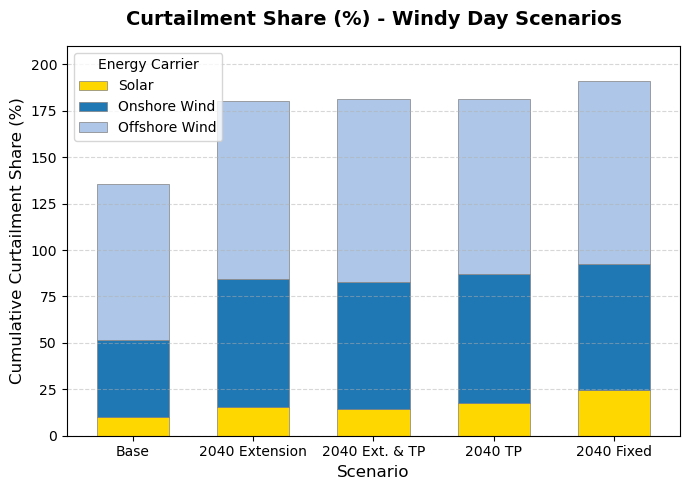

Successfully generated and saved: curtailment_share_stacked_windy.png


<Figure size 640x480 with 0 Axes>

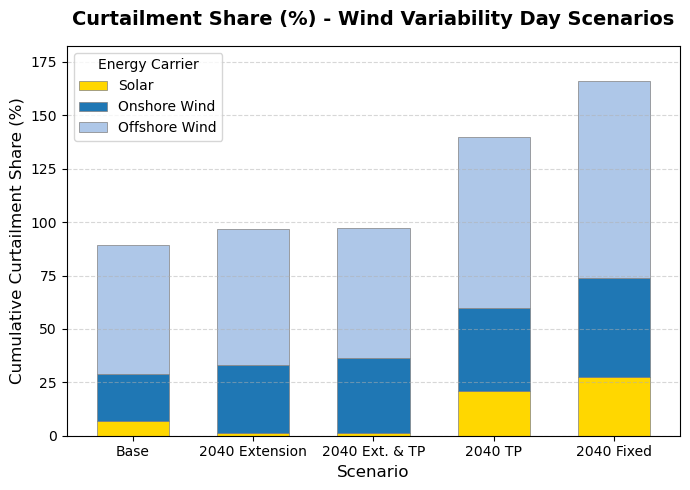

Successfully generated and saved: curtailment_share_stacked_windvariability.png


<Figure size 640x480 with 0 Axes>

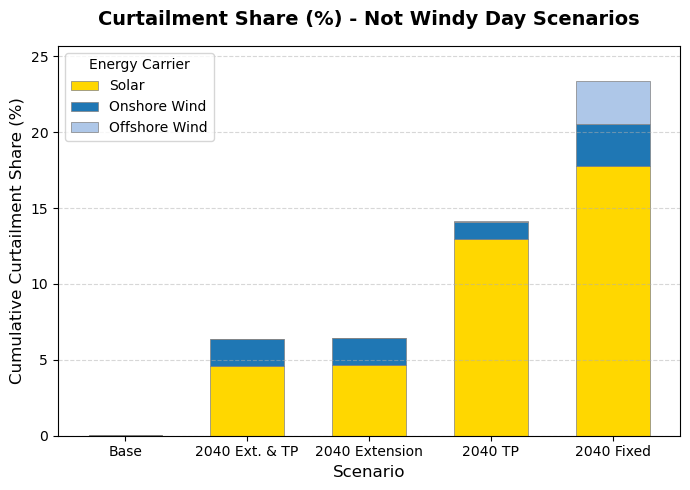

Successfully generated and saved: curtailment_share_stacked_notwindy.png


<Figure size 640x480 with 0 Axes>

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
file_path = f"{csv_directory}curtailment_by_run_carrier_all_networks.csv"
df = pd.read_csv(file_path)

# 2. Filter for relevant carriers
relevant_carriers = ['solar', 'onwind', 'offwind-ac']
df_filtered = df[df['carrier'].isin(relevant_carriers)].copy()

# 3. Map to user-friendly names for the legend
carrier_mapping = {
    'solar': 'Solar',
    'onwind': 'Onshore Wind',
    'offwind-ac': 'Offshore Wind'
}
df_filtered['carrier'] = df_filtered['carrier'].map(carrier_mapping)

# 4. Map raw scenario identifiers to friendly display names using existing mapping (fallback if missing)
try:
    # `scenario_names` may be defined earlier in the notebook; use it when available
    mapping = scenario_names.copy()  # keys -> display names
except Exception:
    # Fallback mapping (no-op)
    mapping = {}

# Normalize keys (strip trailing underscores) so mapping works with variants
norm_map = {k.rstrip('_'): v for k, v in mapping.items()} if mapping else {}

# Derive a 'scenario_base' from the raw scenario label and map to display name
df_filtered['scenario_base'] = df_filtered['scenario'].astype(str).apply(lambda s: s.rsplit('_', 1)[0] if '_' in s else s)
df_filtered['display_name'] = df_filtered['scenario_base'].map(norm_map).fillna(df_filtered['scenario_base'])

# 5. Define the wind conditions and clear titles for each plot
wind_conditions = ['windy', 'windvariability', 'notwindy']
titles = {
    'windy': 'Windy Day Scenarios',
    'windvariability': 'Wind Variability Day Scenarios',
    'notwindy': 'Not Windy Day Scenarios'
}

# 6. Loop through each wind condition and create a separate stacked plot (pivot by display_name)
for wc in wind_conditions:
    # Filter for the current wind condition
    df_wc = df_filtered[df_filtered['wind_condition'] == wc].copy()
    if df_wc.empty:
        print(f"No data for wind condition: {wc}")
        continue

    # Pivot the data to get carriers as columns, indexed by friendly display name
    pivot_df = df_wc.pivot(index='display_name', columns='carrier', values='curtailment_share_pct').fillna(0)

    # Ensure expected columns exist and in desired order
    desired_cols = ['Solar', 'Onshore Wind', 'Offshore Wind']
    for col in desired_cols:
        if col not in pivot_df.columns:
            pivot_df[col] = 0.0
    pivot_df = pivot_df[desired_cols]

    # Sort scenarios within this wind condition by the cumulative total percentage
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(by='Total', ascending=True)
    plot_data = pivot_df[desired_cols]

    # Create the stacked vertical bar chart
    ax = plot_data.plot(
        kind='bar',
        stacked=True,
        figsize=(7, 5),
        color=['#ffd700', '#1f77b4', '#aec7e8'],
        edgecolor='grey',
        linewidth=0.5,
        width=0.6
    )

    # Customize titles, labels, and grids
    plt.title(f'Curtailment Share (%) - {titles.get(wc, wc)}', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Scenario', fontsize=12, )
    plt.ylabel('Cumulative Curtailment Share (%)', fontsize=12)
    plt.legend(title='Energy Carrier', bbox_to_anchor=(0, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0, ha='center')

    # Dynamically set the y-limit to fit the stacked bars nicely
    max_val = plot_data.sum(axis=1).max()
    plt.ylim(0, max_val * 1.1 if max_val > 0 else 100)

    # Automatically adjust layout to prevent label truncation
    plt.tight_layout()

    # Save the individual figure
    filename = f'curtailment_share_stacked_{wc}.png'
    #plt.savefig(filename, dpi=300)
    plt.show()

    # Clear the current figure canvas for the next iteration
    plt.clf()

    print(f"Successfully generated and saved: {filename}")

### From NetCDFs

In [11]:
# Define the base results directory
RESULTS_DIR = Path("/home/lucakristin/Desktop/my_pypsa/pypsa-eur/results")
NETWORK_FILENAME = "base_s_450_elec_.nc"
NETWORKS_SUBFOLDER = "networks"

def parse_network_directory_name(dir_name: str) -> Optional[Tuple[str, str, str]]:
    """
    Parse a network directory name to extract metadata.
    
    Assumes directory names follow the pattern: germany_{scenario}_{wind_condition}
    
    Parameters
    ----------
    dir_name : str
        Directory name (e.g., 'germany_base2_notwindy')
    
    Returns
    -------
    Tuple[str, str, str] or None
        (scenario_name, wind_condition, transmission_setting) or None if invalid
        
    Examples
    --------
    >>> parse_network_directory_name('germany_base2_notwindy')
    ('base2', 'notwindy', 'fixed')
    >>> parse_network_directory_name('germany_scenario-ext_windy')
    ('scenario-ext', 'windy', 'extendable')
    """
    if not dir_name.startswith("germany_"):
        return None
    
    # Remove 'germany_' prefix
    remainder = dir_name[8:]  # len("germany_") = 8
    
    # Wind condition is the last component (notwindy, windy, windvariability)
    wind_conditions = ['notwindy', 'windy', 'windvariability']
    wind_condition = None
    
    for wc in wind_conditions:
        if remainder.endswith(wc):
            wind_condition = wc
            scenario_name = remainder[:-len(wc)-1]  # Remove wind condition and trailing '_'
            break
    
    if wind_condition is None:
        return None
    
    # Define transmission settings based on scenario name
    transmission_map = {
        'base': 'fixed',
        'base2': 'fixed',
        'scenario1': 'fixed',
        'scenario2': 'fixed',
        'scenario-ext': 'extendable + projects',
        'baseTP': 'projects',
        'base-ext': 'extendable',
        'scenario2040-TP': 'projects',
        'scenario2040-ext': 'extendable',
        'scenario2040-fixed': 'fixed'
    }
    
    transmission_setting = transmission_map.get(scenario_name, 'unknown')
    
    return (scenario_name, wind_condition, transmission_setting)


def load_networks_from_results(
    results_dir: Path = RESULTS_DIR,
    network_filename: str = NETWORK_FILENAME,
    networks_subfolder: str = NETWORKS_SUBFOLDER
) -> Dict[Tuple[str, str, str], pypsa.Network]:
    """
    Load all available solved networks from the results directory.
    
    Parameters
    ----------
    results_dir : Path
        Base results directory containing scenario subdirectories
    network_filename : str
        Name of the network file (default: 'base_s_450_elec_.nc')
    networks_subfolder : str
        Subfolder name containing network files (default: 'networks')
    
    Returns
    -------
    Dict[Tuple[str, str, str], pypsa.Network]
        Dictionary with tuple keys (scenario_name, wind_condition, transmission_setting)
    """
    networks = {}
    
    for scenario_dir in sorted(results_dir.iterdir()):
        if not scenario_dir.is_dir():
            continue
        
        # Parse the directory name
        metadata = parse_network_directory_name(scenario_dir.name)
        if metadata is None:
            continue
        
        # Check if network file exists
        network_path = scenario_dir / networks_subfolder / network_filename
        if not network_path.exists():
            print(f"[WARNING] Network file not found: {network_path}")
            continue
        
        try:
            network = pypsa.Network()
            network.import_from_netcdf(str(network_path))
            networks[metadata] = network
        except Exception as e:
            print(f"[ERROR] {e}")
    return networks

# Load networks
networks = load_networks_from_results()
print(f"Available networks: {len(networks)}")

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current:

Available networks: 15


### Results form comparing ALL Networks

In [12]:
csv_dir = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv"

In [13]:
def set_line_widths(top_count, csv_dir=csv_dir, n=n):
    bottlenecks = pd.read_csv(csv_dir + "/bottlenecks.csv")
    if top_count == None:
        top_count = len(bottlenecks)
    top_bottlenecks = bottlenecks[0:top_count]
    top_ids = top_bottlenecks['line_id'].astype(str)
    idx_str = n.lines.index.astype(str)

    line_widths = pd.Series(1, index=n.lines.index)
    line_widths[idx_str.isin(top_ids)] = 4

    return line_widths, bottlenecks[0:top_count]

NameError: name 'n' is not defined

In [14]:

n = networks[('scenario2040-fixed', 'windy', 'fixed')]
line_widths, bottlenecks = set_line_widths(top_count=None, csv_dir=csv_dir, n=n)


NameError: name 'set_line_widths' is not defined

NameError: name 'line_widths' is not defined

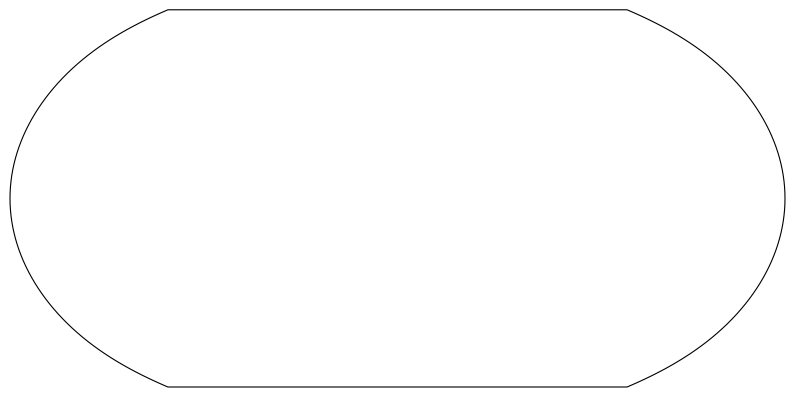

In [15]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

n.plot(
    ax=ax,
    geomap=True,
    title="Top congested lines across all scenarios",
    bus_sizes=0.003,
    bus_alpha=0.7,
    line_widths= line_widths,
    line_colors= line_widths,
    line_cmap="RdYlGn_r",
)

In [16]:
avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()

map=n.explore(
    line_color=avg_loading_n,
    line_width= line_widths,
    line_cmap="YlOrRd",
    bus_alpha=0.2,
    line_alpha=0.5,
    bus_color = "lightblue",
)
map.to_html("exploring_new.html")

NameError: name 'line_widths' is not defined

### Comparing a subset of networks

In [17]:
csv_dir = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/fixed/"
n = networks[('base2', 'windy', 'fixed')]
top_count = 30
line_widths, bottlenecks= set_line_widths(top_count, csv_dir, n)

avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()

map2=n.explore(
    line_color=avg_loading_n,
    line_width= line_widths,
    line_cmap="YlOrRd",
    bus_alpha=0.2,
    line_alpha=0.5,
    bus_color = "lightblue",
)
map2.to_html("exploring_fixed.html")

print(bottlenecks)

NameError: name 'set_line_widths' is not defined

In [18]:
csv_dir = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/wind/"
n = networks[('base2', 'windy', 'fixed')]
top_count = None
line_widths, bottlenecks = set_line_widths(top_count, csv_dir, n)

avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()

map=n.explore(
    line_color=avg_loading_n,
    line_width= line_widths,
    line_cmap="YlOrRd",
    bus_alpha=0.2,
    line_alpha=0.5,
    bus_color = "lightblue",
)
map.to_html("exploring_wind.html")
print(bottlenecks)

NameError: name 'set_line_widths' is not defined